# scVI Baseline for Single-Cell RNA-seq Analysis

This notebook provides a baseline implementation using [scVI] for single-cell RNA-seq data analysis.

## 📋 Prerequisites

Before running this baseline, please ensure you have:

1. **Followed the main installation guide** in the root directory's README to set up the conda environment
2. **Installed additional dependencies** specific to scVI:

```bash
# Activate the scE2TM environment first
conda activate scE2TM_env

# Install scVI and its dependencies (with torch version locked to match your environment)
pip install scvi-tools==0.14.0 torch==1.9.1+cu102 -f https://download.pytorch.org/whl/torch_stable.html

# Install torchmetrics without dependencies (to avoid version conflicts)
pip install torchmetrics==0.5.0 --no-deps

Global seed set to 0


Current working directory: /mnt/rao/home/chenhg/Methods/ECRTM-Singlecell/scE2TM_github/baseline
Loading data from: /mnt/rao/home/chenhg/Methods/ECRTM-Singlecell/scE2TM_github/baseline/../data/Wang_HIGHPRE.csv
Loading labels from: /mnt/rao/home/chenhg/Methods/ECRTM-Singlecell/scE2TM_github/baseline/../data/Wang_cell_anno.csv
Outputs will be saved to: /mnt/rao/home/chenhg/Methods/ECRTM-Singlecell/scE2TM_github/baseline/output
Data shape: (457, 5000)
INFO     No batch_key inputted, assuming all cells are same batch                                                  
INFO     No label_key inputted, assuming all cells have same label                                                 
INFO     Using data from adata.X                                                                                   
INFO     Successfully registered anndata object containing 457 cells, 5000 vars, 1 batches, 1 labels, and 0        
         proteins. Also registered 0 extra categorical covariates and 0 extra contin

/mnt/rao/home/chenhg/anaconda3/envs/scE2TM_test/lib/python3.8/site-packages/scvi/model/base/_base_model.py:150: UserWarning: Make sure the registered X field in anndata contains unnormalized count data.
  warnings.warn(
GPU available: True, used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Epoch 2/400:   0%|          | 1/400 [00:00<01:17,  5.15it/s, loss=9.75e+03, v_num=1]

/mnt/rao/home/chenhg/anaconda3/envs/scE2TM_test/lib/python3.8/site-packages/scvi/distributions/_negative_binomial.py:433: UserWarning: The value argument must be within the support of the distribution
  warnings.warn(


...

/mnt/rao/home/chenhg/anaconda3/envs/scE2TM_test/lib/python3.8/site-packages/scvi/distributions/_negative_binomial.py:433: UserWarning: The value argument must be within the support of the distribution
  warnings.warn(


Epoch 400/400: 100%|██████████| 400/400 [01:18<00:00,  5.08it/s, loss=4.38e+03, v_num=1]


/mnt/rao/home/chenhg/anaconda3/envs/scE2TM_test/lib/python3.8/site-packages/scvi/model/base/_base_model.py:150: UserWarning: Make sure the registered X field in anndata contains unnormalized count data.
  warnings.warn(


Latent representation shape: (457, 100)
Number of cell types: 7
Cells with valid labels: 457/457
Searching for optimal clustering resolution...
Resolution 0.0: ARI = 0.0000
Resolution 0.1: ARI = 0.0000
Resolution 0.2: ARI = 0.3900
Resolution 0.3: ARI = 0.3900
Resolution 0.4: ARI = 0.3900
Resolution 0.5: ARI = 0.3854
Resolution 0.6: ARI = 0.7133
Resolution 0.7: ARI = 0.7366
Resolution 0.8: ARI = 0.6153
Resolution 0.9: ARI = 0.6694
Resolution 1.0: ARI = 0.6369
Resolution 1.1: ARI = 0.6354
Resolution 1.2: ARI = 0.6283
Resolution 1.3: ARI = 0.6254
Resolution 1.4: ARI = 0.6147
Resolution 1.5: ARI = 0.6180
Resolution 1.6: ARI = 0.5583
Resolution 1.7: ARI = 0.5980
Resolution 1.8: ARI = 0.5061
Resolution 1.9: ARI = 0.5290
Best resolution: 0.7 (ARI = 0.7366)


/mnt/rao/home/chenhg/anaconda3/envs/scE2TM_test/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/mnt/rao/home/chenhg/anaconda3/envs/scE2TM_test/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


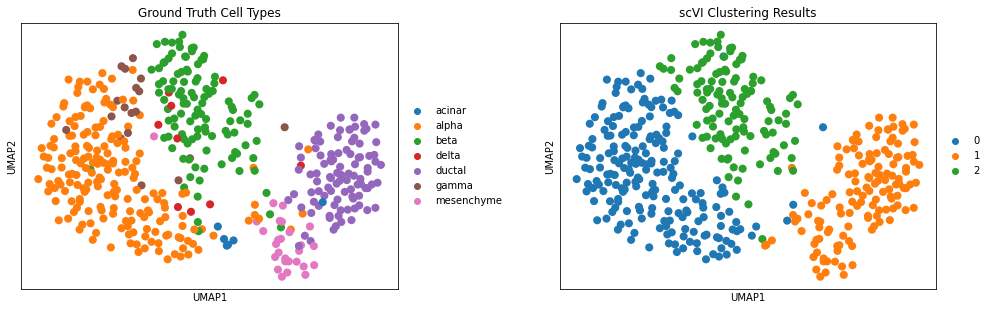


EVALUATION METRICS
Adjusted Rand Index (ARI):      0.7366
Adjusted Mutual Information (AMI): 0.6752
Average Silhouette Width (ASW): 0.0444
Purity Score (based on dominant latent dimension): 0.6521

SAVING OUTPUTS
All outputs will be saved to: /mnt/rao/home/chenhg/Methods/ECRTM-Singlecell/scE2TM_github/baseline/output
✓ Cell embeddings saved: SCVI_Wang_embedding.csv
DONE!


In [1]:
"""
scVI baseline implementation for single-cell RNA-seq analysis
This script performs dimensionality reduction, clustering, and evaluation using scVI
"""

import scvi
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, silhouette_score
from sklearn import metrics
import os
import sys

# Get the current directory - works in both Jupyter notebook and Python scripts
try:
    # This works when running as a script
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # This works in Jupyter notebook
    current_dir = os.getcwd()

print(f"Current working directory: {current_dir}")

# Define data paths (relative to the script location)
data_name = 'Wang'  # Base name for the data files
data_path = os.path.join(current_dir, '..', 'data', f'{data_name}_HIGHPRE.csv')  # Expression data
label_path = os.path.join(current_dir, '..', 'data', f'{data_name}_cell_anno.csv')  # Cell type annotations

# Define output directory (create if it doesn't exist)
output_dir = os.path.join(current_dir, 'output')
os.makedirs(output_dir, exist_ok=True)

print(f"Loading data from: {data_path}")
print(f"Loading labels from: {label_path}")
print(f"Outputs will be saved to: {output_dir}")

# Check if files exist
if not os.path.exists(data_path):
    print(f"ERROR: Data file not found at {data_path}")
    print("Please make sure the data file is in the correct location.")
    print("Expected structure:")
    print("  scE2TM/")
    print("  ├── baseline/")
    print("  │   ├── scVI.ipynb (this notebook)")
    print("  │   └── output/ (will be created)")
    print("  └── data/")
    print("      ├── Wang_HIGHPRE.csv")
    print("      └── Wang_cell_anno.csv")
    sys.exit(1)

if not os.path.exists(label_path):
    print(f"ERROR: Label file not found at {label_path}")
    print("Please make sure the label file is in the correct location.")
    sys.exit(1)

# Load expression data
# The data should be in CSV format with genes as columns and cells as rows
scvi_csv = pd.read_csv(data_path, sep=',', index_col=0)
print(f"Data shape: {scvi_csv.shape}")

# Create AnnData object (standard format for single-cell data)
scvi_adata = sc.AnnData(scvi_csv)

# Setup scVI model
# This prepares the AnnData object for scVI training
scvi.model.SCVI.setup_anndata(scvi_adata)

# Initialize and train scVI model
# n_latent: dimension of the latent space (default is 10, we use 100 for better representation)
model = scvi.model.SCVI(scvi_adata, n_latent=100)
print("Training scVI model...")
model.train(use_gpu=0)  # Use GPU 0 for training

# Extract latent representation (low-dimensional embedding)
latent = model.get_latent_representation()
scvi_adata.obsm["X_scVI"] = latent
print(f"Latent representation shape: {latent.shape}")

# Load cell type labels
# These are the ground truth labels for evaluation
scvi_label_csv = pd.read_csv(label_path, sep=',', index_col=0)
scvi_adata.obs['cell_type'] = list(scvi_label_csv.iloc[:, 0])
print(f"Number of cell types: {len(scvi_adata.obs['cell_type'].unique())}")

# Handle potential NaN values in labels
non_nan_indices = [i for i, x in enumerate(scvi_adata.obs['cell_type']) if pd.notna(x)]
print(f"Cells with valid labels: {len(non_nan_indices)}/{len(scvi_adata.obs['cell_type'])}")

# Construct neighborhood graph using scVI latent representation
sc.pp.neighbors(scvi_adata, n_neighbors=15, use_rep="X_scVI")

# Find optimal resolution for Louvain clustering
# We search over a range of resolutions to maximize ARI
max_resolution = 2  # Maximum resolution to test
min_resolution = 0  # Minimum resolution to test
n_steps = 20  # Number of resolution steps (max_resolution * 10)
ari_scores = []

print("Searching for optimal clustering resolution...")
for i in range(min_resolution, n_steps):
    resolution = i / 10.0
    sc.tl.louvain(scvi_adata, resolution=resolution, random_state=0)
    # Only use cells with valid labels for ARI calculation
    ari = adjusted_rand_score(
        scvi_adata.obs['cell_type'][non_nan_indices], 
        scvi_adata.obs['louvain'][non_nan_indices]
    )
    ari_scores.append(ari)
    print(f"Resolution {resolution:.1f}: ARI = {ari:.4f}")

# Select the resolution that gives the highest ARI
best_resolution = ari_scores.index(max(ari_scores)) * 0.1
print(f"Best resolution: {best_resolution:.1f} (ARI = {max(ari_scores):.4f})")

# Perform final clustering with optimal resolution
sc.tl.louvain(scvi_adata, resolution=best_resolution, random_state=0)

# Compute UMAP for visualization
sc.tl.umap(scvi_adata)

# Visualize results
sc.pl.umap(
    scvi_adata,
    color=["cell_type", "louvain"],
    wspace=0.3,
    title=['Ground Truth Cell Types', 'scVI Clustering Results']
    # Uncomment the line below to save the figure
    # save=os.path.join(output_dir, 'scVI_umap.pdf')
)

# Calculate and print evaluation metrics
ari = adjusted_rand_score(
    scvi_adata.obs['cell_type'][non_nan_indices], 
    scvi_adata.obs['louvain'][non_nan_indices]
)
ami = adjusted_mutual_info_score(
    scvi_adata.obs['cell_type'][non_nan_indices], 
    scvi_adata.obs['louvain'][non_nan_indices]
)
asw = silhouette_score(
    scvi_adata.obsm["X_scVI"][non_nan_indices], 
    scvi_adata.obs['cell_type'][non_nan_indices]
)

print("\n" + "="*50)
print("EVALUATION METRICS")
print("="*50)
print(f"Adjusted Rand Index (ARI):      {ari:.4f}")
print(f"Adjusted Mutual Information (AMI): {ami:.4f}")
print(f"Average Silhouette Width (ASW): {asw:.4f}")
print("="*50)

# Calculate purity score based on dominant latent dimension
dominant_topics = np.argmax(scvi_adata.obsm["X_scVI"], axis=1)

def purity_score(y_true, y_pred):
    """
    Calculate purity score for clustering evaluation
    Purity measures the extent to which each cluster contains only cells from a single class
    """
    contingency_matrix = metrics.cluster.contingency_matrix(y_true, y_pred)
    return np.sum(np.amax(contingency_matrix, axis=0)) / np.sum(contingency_matrix)

purity = purity_score(
    scvi_adata.obs['cell_type'][non_nan_indices], 
    dominant_topics[non_nan_indices]
)
print(f"Purity Score (based on dominant latent dimension): {purity:.4f}")
print("="*50)

# ============================================================
# SAVE OUTPUTS
# ============================================================
print("\n" + "="*50)
print("SAVING OUTPUTS")
print("="*50)
print(f"All outputs will be saved to: {output_dir}")

# Save cell embeddings
embedding_path = os.path.join(output_dir, f'SCVI_{data_name}_embedding.csv')
pd.DataFrame(latent,
             index=scvi_adata.obs_names,
             columns=[f'Dim_{i+1}' for i in range(latent.shape[1])]).to_csv(embedding_path)
print(f"✓ Cell embeddings saved: SCVI_{data_name}_embedding.csv")

print("="*50)
print("DONE!")
print("="*50)